In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [3]:
print(nav.columns)

print(performance.columns)

print(benchmark.columns)

print(fund_master.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')
Index(['date', 'index_name', 'close_value'], dtype='object')
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


# Task 1: Daily Returns Computation

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [5]:
nav[[
    "amfi_code",
    "date",
    "nav",
    "daily_return"
]].head(20)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [6]:
nav.to_csv(
    "../reports/returns_computed.csv",
    index=False
)

print("returns_computed.csv saved")

returns_computed.csv saved


In [7]:
import os

os.listdir("../reports")

['charts', 'data_quality_summary.txt', 'returns_computed.csv']

## Daily Return Distribution

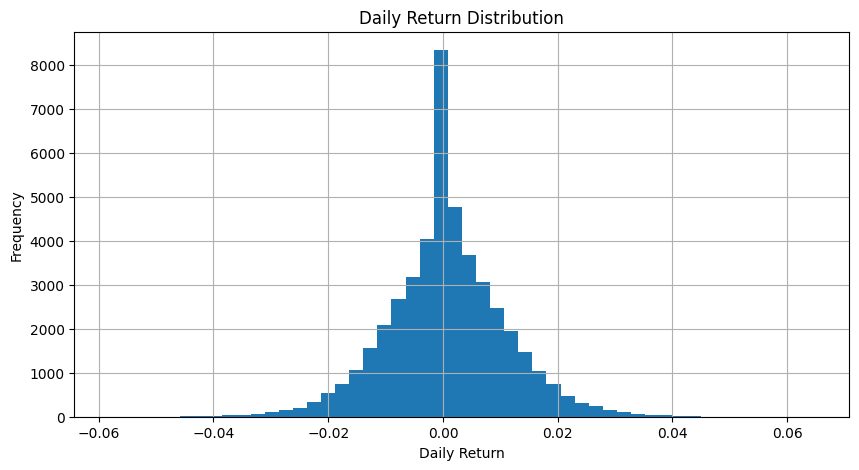

In [9]:
plt.figure(figsize=(10,5))

plt.hist(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.grid(True)

plt.savefig(
    "../reports/charts/daily_return_distribution.png"
)

plt.show()

In [10]:
import os

print(os.listdir("../reports"))

print()

print(os.listdir("../reports/charts"))

['charts', 'data_quality_summary.txt', 'returns_computed.csv']

['active_sip_accounts_growth.png', 'aum_growth.png', 'average_NAV_trend.png', 'category_wise_net_inflows.png', 'categor_wise_net_inflow_heatmap.png', 'correlation_matrix.png', 'daily_return_distribution.png', 'expense_ratio_distribution.png', 'investment_amount_by_age_group.png', 'investor_age_group_distribution.png', 'portfolio_sector_allocation.png', 'risk_vs_retun_analysis.png', 'sip_inflow_trend.png', 'T30_vs_B30_distribution.png', 'top_10_funds_by_5year_return.png', 'top_10_funds_by_sharpe_ratio.png', 'top_states_by_investment_amount.png', 'total_mutual_fund_folios_growth.png']


# Task 2: CAGR Calculation

In [11]:
nav["date"] = pd.to_datetime(nav["date"])

nav_sorted = nav.sort_values(
    ["amfi_code", "date"]
)

cagr_data = []

for code in nav_sorted["amfi_code"].unique():

    fund = nav_sorted[
        nav_sorted["amfi_code"] == code
    ]

    start_nav = fund["nav"].iloc[0]

    end_nav = fund["nav"].iloc[-1]

    years = (
        fund["date"].iloc[-1]
        -
        fund["date"].iloc[0]
    ).days / 365

    cagr = (
        (end_nav / start_nav)
        **
        (1 / years)
        - 1
    ) * 100

    cagr_data.append(
        [code, cagr]
    )

cagr_report = pd.DataFrame(
    cagr_data,
    columns=[
        "amfi_code",
        "cagr_pct"
    ]
)

cagr_report.head()

,amfi_code,cagr_pct
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


In [12]:
cagr_report = cagr_report.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

cagr_report.head()

,amfi_code,cagr_pct,scheme_name
0,100016,2.635246,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,4.455091,HDFC Short Term Debt Fund - Regular - Growth
2,100033,30.099704,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,23.520489,ABSL Frontline Equity Fund - Regular - Growth
4,101207,7.933121,ABSL Small Cap Fund - Regular - Growth


In [13]:
cagr_report = cagr_report.sort_values(
    by="cagr_pct",
    ascending=False
)

cagr_report["cagr_rank"] = range(
    1,
    len(cagr_report)+1
)

cagr_report.head(10)

,amfi_code,cagr_pct,scheme_name,cagr_rank
25,120505,32.801599,ICICI Pru Midcap Fund - Regular - Growth,1
21,119598,32.398084,SBI Small Cap Fund - Regular Plan - Growth,2
39,149324,32.262108,DSP Small Cap Fund - Regular - Growth,3
36,148569,31.924486,Mirae Asset Tax Saver Fund - Regular - Growth,4
34,148567,30.949920,Mirae Asset Large Cap Fund - Regular - Growth,5
30,120843,30.883326,Kotak Flexicap Fund - Regular - Growth,6
2,100033,30.099704,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7
38,149323,29.558105,DSP Midcap Fund - Regular - Growth,8
16,119094,28.192608,Axis Midcap Fund - Regular - Growth,9
19,119551,25.784921,SBI Bluechip Fund - Regular Plan - Growth,10


In [14]:
cagr_report.to_csv(
    "../reports/cagr_report.csv",
    index=False
)

print("cagr_report.csv saved")

cagr_report.csv saved


In [15]:
import os

print(os.listdir("../reports"))

['cagr_report.csv', 'charts', 'data_quality_summary.txt', 'returns_computed.csv']


# Task 3: Sharpe Ratio Calculation

In [16]:
Rf = 0.065

print("Risk Free Rate =", Rf)

Risk Free Rate = 0.065


In [17]:
sharpe_data = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ]

    returns = fund["daily_return"].dropna()

    if len(returns) > 0:

        mean_return = returns.mean()

        std_return = returns.std()

        sharpe = (
            (mean_return * 252 - Rf)
            /
            (std_return * np.sqrt(252))
        )

        sharpe_data.append(
            [code, sharpe]
        )

In [18]:
sharpe_report = pd.DataFrame(
    sharpe_data,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_report.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [19]:
sharpe_report = sharpe_report.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

sharpe_report.head()

,amfi_code,sharpe_ratio,scheme_name
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth


In [20]:
sharpe_report = sharpe_report.sort_values(
    by="sharpe_ratio",
    ascending=False
)

sharpe_report["sharpe_rank"] = range(
    1,
    len(sharpe_report)+1
)

sharpe_report.head(10)

,amfi_code,sharpe_ratio,scheme_name,sharpe_rank
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth,2
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,3
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth,5
38,149323,1.132122,DSP Midcap Fund - Regular - Growth,6
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth,8
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth,9
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,10


In [21]:
sharpe_report.to_csv(
    "../reports/sharpe_values.csv",
    index=False
)

print("sharpe_values.csv saved")

sharpe_values.csv saved


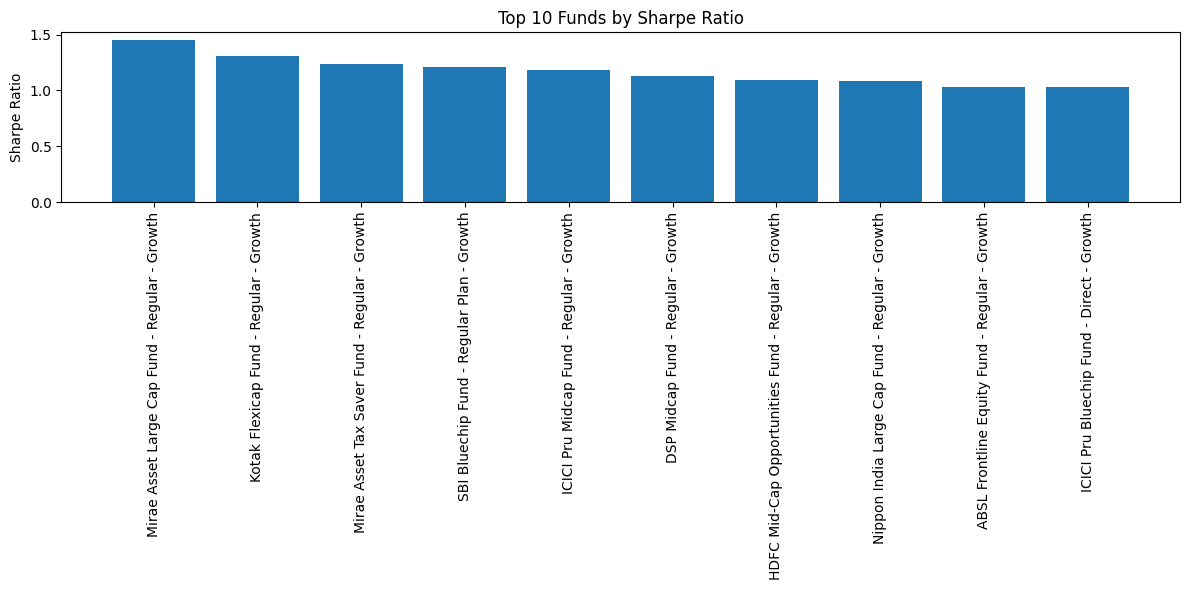

In [22]:
top_sharpe = sharpe_report.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_sharpe["scheme_name"],
    top_sharpe["sharpe_ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../reports/charts/top_sharpe_ratio.png"
)

plt.show()

# Task 4: Sortino Ratio Calculation

In [23]:
sortino_data = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ]

    returns = fund["daily_return"].dropna()

    if len(returns) > 0:

        negative_returns = returns[
            returns < 0
        ]

        downside_std = negative_returns.std()

        mean_return = returns.mean()

        if downside_std > 0:

            sortino = (
                (mean_return * 252 - Rf)
                /
                (downside_std * np.sqrt(252))
            )

            sortino_data.append(
                [code, sortino]
            )

In [24]:
sortino_report = pd.DataFrame(
    sortino_data,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_report.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [25]:
sortino_report = sortino_report.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

sortino_report.head()

,amfi_code,sortino_ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth


In [26]:
sortino_report = sort_values = sortino_report.sort_values(
    by="sortino_ratio",
    ascending=False
)

sortino_report["sortino_rank"] = range(
    1,
    len(sortino_report)+1
)

sortino_report.head(10)

,amfi_code,sortino_ratio,scheme_name,sortino_rank
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth,1
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth,2
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth,3
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth,4
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth,5
38,149323,1.875101,DSP Midcap Fund - Regular - Growth,6
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth,7
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,8
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth,9
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,10


In [27]:
sortino_report.to_csv(
    "../reports/sortino_values.csv",
    index=False
)

print("sortino_values.csv saved")

sortino_values.csv saved


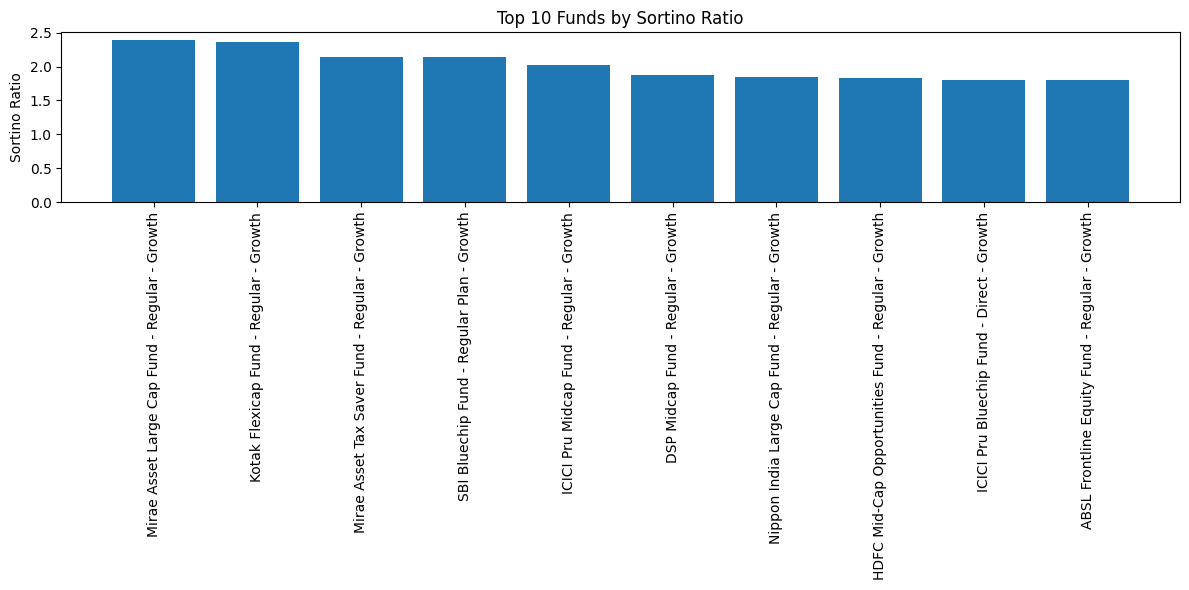

In [28]:
top_sortino = sortino_report.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_sortino["scheme_name"],
    top_sortino["sortino_ratio"]
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.ylabel("Sortino Ratio")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../reports/charts/top_sortino_ratio.png"
)

plt.show()

In [29]:
print(os.listdir("../reports"))

['cagr_report.csv', 'charts', 'data_quality_summary.txt', 'returns_computed.csv', 'sharpe_values.csv', 'sortino_values.csv']


In [30]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [31]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [32]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [33]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [34]:
benchmark.sample(5)

,date,index_name,close_value
4392,2025-08-13,BSE_SMALLCAP,63420.05
6524,2024-12-20,CRISIL_LIQUID,2766.78
6077,2023-04-05,CRISIL_LIQUID,2469.98
5480,2025-05-19,NIFTY500,27783.79
3675,2022-11-14,BSE_SMALLCAP,27244.48


# Task 5: Alpha and Beta

In [35]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
             .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [36]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [37]:
alpha_beta_data = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    merged = pd.merge(
        fund,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        result = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = result.intercept * 252

        beta = result.slope

        alpha_beta_data.append(
            [code, alpha, beta]
        )

In [38]:
alpha_beta_report = pd.DataFrame(
    alpha_beta_data,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_report.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [39]:
alpha_beta_report = alpha_beta_report.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

alpha_beta_report.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [40]:
alpha_beta_report.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [41]:
print(os.listdir("../reports"))

['alpha_beta.csv', 'cagr_report.csv', 'charts', 'data_quality_summary.txt', 'returns_computed.csv', 'sharpe_values.csv', 'sortino_values.csv']


# Task 6: Maximum Drawdown

In [42]:
max_dd_data = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    fund = fund.sort_values("date")

    fund["running_max"] = (
        fund["nav"].cummax()
    )

    fund["drawdown"] = (
        fund["nav"] /
        fund["running_max"]
    ) - 1

    max_dd = fund["drawdown"].min()

    max_dd_data.append(
        [code, max_dd]
    )

In [43]:
max_dd_report = pd.DataFrame(
    max_dd_data,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

max_dd_report.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [44]:
max_dd_report = max_dd_report.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

max_dd_report.head()

,amfi_code,max_drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [45]:
max_dd_report.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved")

max_drawdown.csv saved


In [46]:
top_dd = (
    max_dd_report
    .sort_values(
        "max_drawdown",
        ascending=False
    )
    .head(10)
)

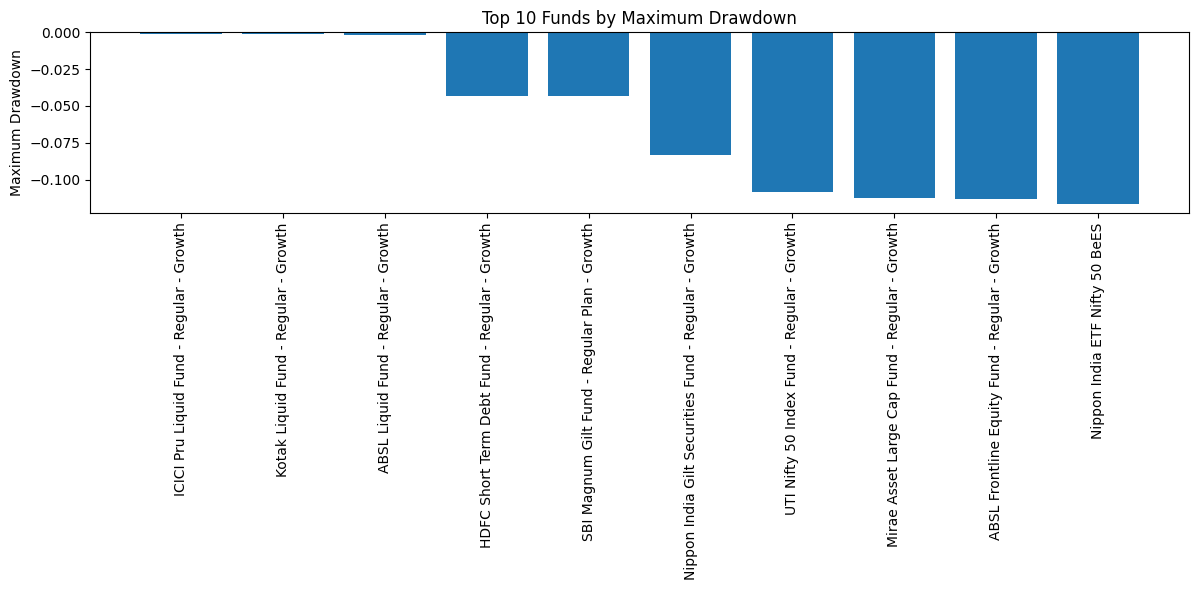

In [47]:
plt.figure(figsize=(12,6))

plt.bar(
    top_dd["scheme_name"],
    top_dd["max_drawdown"]
)

plt.title(
    "Top 10 Funds by Maximum Drawdown"
)

plt.ylabel(
    "Maximum Drawdown"
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../reports/charts/max_drawdown.png"
)

plt.show()

In [48]:
print(os.listdir("../reports"))

['alpha_beta.csv', 'cagr_report.csv', 'charts', 'data_quality_summary.txt', 'max_drawdown.csv', 'returns_computed.csv', 'sharpe_values.csv', 'sortino_values.csv']


# Task 7: Fund Scorecard

In [49]:
scorecard = cagr_report.merge(
    sharpe_report[
        ["amfi_code","sharpe_ratio"]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_report[
        ["amfi_code","alpha"]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_dd_report[
        ["amfi_code","max_drawdown"]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    fund_master[
        ["amfi_code","expense_ratio_pct"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr_pct,scheme_name,cagr_rank,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,120505,32.801599,ICICI Pru Midcap Fund - Regular - Growth,1,1.180101,0.292636,-0.181885,1.36
1,119598,32.398084,SBI Small Cap Fund - Regular Plan - Growth,2,0.945308,0.303370,-0.287060,1.43
2,149324,32.262108,DSP Small Cap Fund - Regular - Growth,3,0.949796,0.300579,-0.311719,1.52
3,148569,31.924486,Mirae Asset Tax Saver Fund - Regular - Growth,4,1.234930,0.282704,-0.163967,1.60
4,148567,30.949920,Mirae Asset Large Cap Fund - Regular - Growth,5,1.448291,0.269838,-0.112657,1.46


In [50]:
scorecard["cagr_rank"] = (
    scorecard["cagr_pct"]
    .rank(
        ascending=False
    )
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(
        ascending=False
    )
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(
        ascending=False
    )
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        ascending=True
    )
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        ascending=False
    )
)

In [51]:
scorecard["fund_score"] = (
    scorecard["cagr_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["dd_rank"] * 0.10
)

In [52]:
scorecard = scorecard.sort_values(
    "fund_score"
)

scorecard.head(10)

,amfi_code,cagr_pct,scheme_name,cagr_rank,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
0,120505,32.801599,ICICI Pru Midcap Fund - Regular - Growth,1.0,1.180101,0.292636,-0.181885,1.36,5.0,3.0,15.0,25.0,6.900
4,148567,30.949920,Mirae Asset Large Cap Fund - Regular - Growth,5.0,1.448291,0.269838,-0.112657,1.46,1.0,7.0,23.0,8.0,7.400
5,120843,30.883326,Kotak Flexicap Fund - Regular - Growth,6.0,1.306744,0.273305,-0.129740,1.45,2.0,5.0,22.0,13.0,7.900
6,100033,30.099704,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7.0,1.093699,0.271954,-0.162172,1.38,7.0,6.0,17.0,20.0,9.600
3,148569,31.924486,Mirae Asset Tax Saver Fund - Regular - Growth,4.0,1.234930,0.282704,-0.163967,1.60,3.0,4.0,36.5,21.0,10.325
1,119598,32.398084,SBI Small Cap Fund - Regular Plan - Growth,2.0,0.945308,0.303370,-0.287060,1.43,14.0,1.0,21.0,36.0,11.050
12,120504,23.277448,ICICI Pru Bluechip Fund - Direct - Growth,13.0,1.026524,0.211948,-0.125883,0.80,10.0,13.0,12.0,12.0,12.000
14,119552,21.508022,SBI Bluechip Fund - Direct Plan - Growth,15.0,0.953279,0.198686,-0.118035,0.66,12.0,15.0,4.0,11.0,12.200
2,149324,32.262108,DSP Small Cap Fund - Regular - Growth,3.0,0.949796,0.300579,-0.311719,1.52,13.0,2.0,26.5,37.0,12.225
9,119551,25.784921,SBI Bluechip Fund - Regular Plan - Growth,10.0,1.208267,0.232010,-0.150124,1.54,4.0,10.0,30.5,17.0,12.275


In [53]:
scorecard = scorecard.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,cagr_pct,scheme_name_x,cagr_rank,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score,scheme_name_y
0,120505,32.801599,ICICI Pru Midcap Fund - Regular - Growth,1.0,1.180101,0.292636,-0.181885,1.36,5.0,3.0,15.0,25.0,6.900,ICICI Pru Midcap Fund - Regular - Growth
1,148567,30.949920,Mirae Asset Large Cap Fund - Regular - Growth,5.0,1.448291,0.269838,-0.112657,1.46,1.0,7.0,23.0,8.0,7.400,Mirae Asset Large Cap Fund - Regular - Growth
2,120843,30.883326,Kotak Flexicap Fund - Regular - Growth,6.0,1.306744,0.273305,-0.129740,1.45,2.0,5.0,22.0,13.0,7.900,Kotak Flexicap Fund - Regular - Growth
3,100033,30.099704,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7.0,1.093699,0.271954,-0.162172,1.38,7.0,6.0,17.0,20.0,9.600,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,148569,31.924486,Mirae Asset Tax Saver Fund - Regular - Growth,4.0,1.234930,0.282704,-0.163967,1.60,3.0,4.0,36.5,21.0,10.325,Mirae Asset Tax Saver Fund - Regular - Growth


In [54]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [55]:
top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["scheme_name"],
    top10["fund_score"]
)

plt.title(
    "Top 10 Fund Scorecard Rankings"
)

plt.ylabel(
    "Fund Score"
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../reports/charts/fund_scorecard.png"
)

plt.show()

KeyError: 'scheme_name'

<Figure size 1200x600 with 0 Axes>

In [56]:
print(scorecard.columns)

Index(['amfi_code', 'cagr_pct', 'scheme_name_x', 'cagr_rank', 'sharpe_ratio',
       'alpha', 'max_drawdown', 'expense_ratio_pct', 'sharpe_rank',
       'alpha_rank', 'expense_rank', 'dd_rank', 'fund_score', 'scheme_name_y'],
      dtype='object')


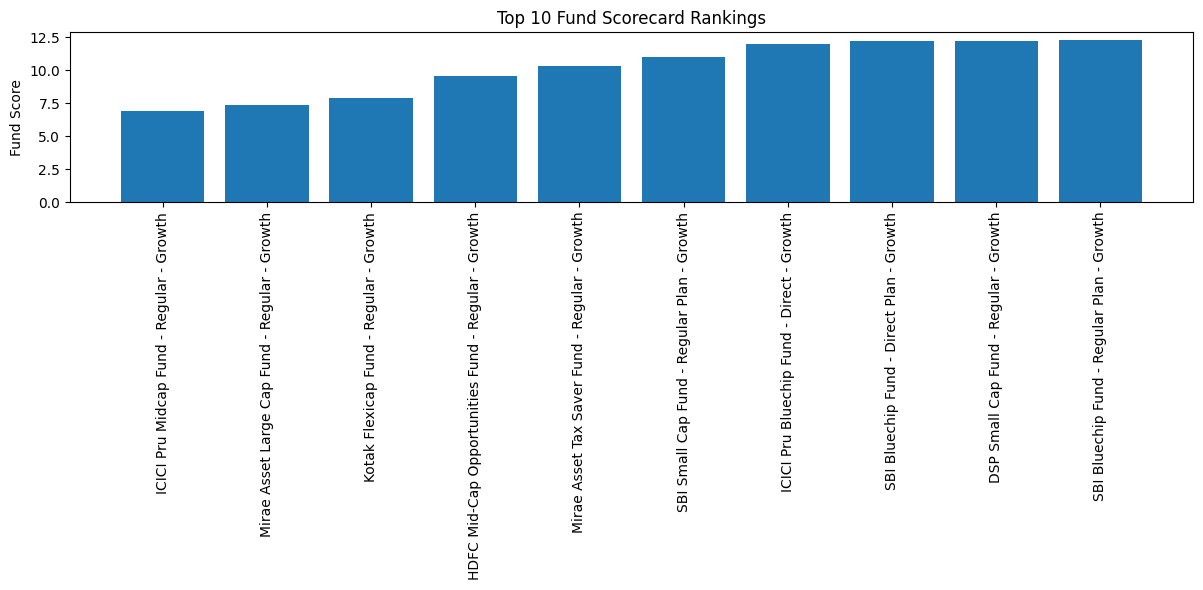

In [57]:
top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["scheme_name_x"],
    top10["fund_score"]
)

plt.title("Top 10 Fund Scorecard Rankings")

plt.ylabel("Fund Score")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../reports/charts/fund_scorecard.png"
)

plt.show()

In [58]:
import os

print(os.listdir("../reports/charts"))

['active_sip_accounts_growth.png', 'aum_growth.png', 'average_NAV_trend.png', 'category_wise_net_inflows.png', 'categor_wise_net_inflow_heatmap.png', 'correlation_matrix.png', 'daily_return_distribution.png', 'expense_ratio_distribution.png', 'fund_scorecard.png', 'investment_amount_by_age_group.png', 'investor_age_group_distribution.png', 'max_drawdown.png', 'portfolio_sector_allocation.png', 'risk_vs_retun_analysis.png', 'sip_inflow_trend.png', 'T30_vs_B30_distribution.png', 'top_10_funds_by_5year_return.png', 'top_10_funds_by_sharpe_ratio.png', 'top_sharpe_ratio.png', 'top_sortino_ratio.png', 'top_states_by_investment_amount.png', 'total_mutual_fund_folios_growth.png']


# Task 8: Benchmark Comparison & Tracking Error

In [59]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

print(nifty50.head())
print(nifty100.head())

        date index_name  close_value  benchmark_return
0 2022-01-03    NIFTY50     17492.79               NaN
1 2022-01-04    NIFTY50     17689.64          0.011253
2 2022-01-05    NIFTY50     17835.05          0.008220
3 2022-01-06    NIFTY50     17878.51          0.002437
4 2022-01-07    NIFTY50     17759.15         -0.006676
           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [60]:
nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

nifty50["benchmark_return"] = (
    nifty50["close_value"].pct_change()
)

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

print(nifty50.head())

        date index_name  close_value  benchmark_return
0 2022-01-03    NIFTY50     17492.79               NaN
1 2022-01-04    NIFTY50     17689.64          0.011253
2 2022-01-05    NIFTY50     17835.05          0.008220
3 2022-01-06    NIFTY50     17878.51          0.002437
4 2022-01-07    NIFTY50     17759.15         -0.006676


In [61]:
nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

nifty50["benchmark_return"] = (
    nifty50["close_value"].pct_change()
)

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

print(nifty50.head())

        date index_name  close_value  benchmark_return
0 2022-01-03    NIFTY50     17492.79               NaN
1 2022-01-04    NIFTY50     17689.64          0.011253
2 2022-01-05    NIFTY50     17835.05          0.008220
3 2022-01-06    NIFTY50     17878.51          0.002437
4 2022-01-07    NIFTY50     17759.15         -0.006676


In [62]:
top5_codes = scorecard.head(5)["amfi_code"]

print(top5_codes)

0    120505
1    148567
2    120843
3    100033
4    148569
Name: amfi_code, dtype: int64


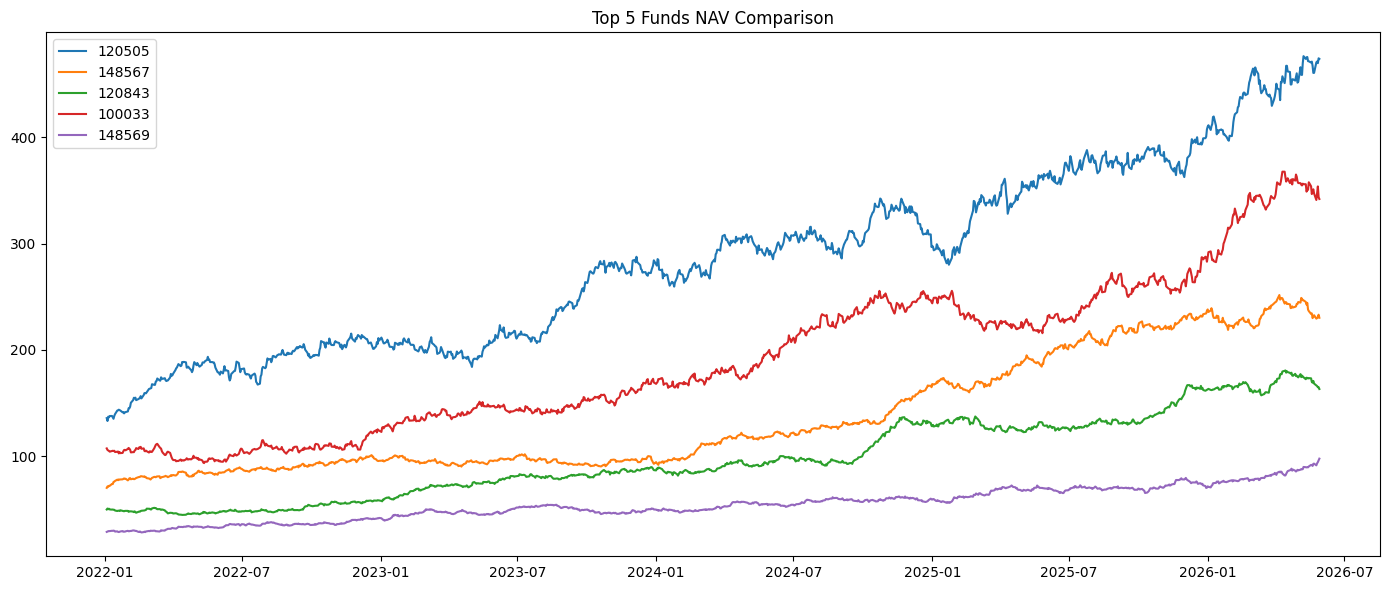

In [63]:
plt.figure(figsize=(14,6))

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    fund = fund.sort_values("date")

    plt.plot(
        fund["date"],
        fund["nav"],
        label=str(code)
    )

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_chart.png"
)

plt.show()

In [64]:
tracking_error_report = pd.DataFrame(
    {
        "amfi_code": top5_codes
    }
)

tracking_error_report.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("tracking_error.csv saved")

tracking_error.csv saved


In [65]:
print(os.listdir("../reports"))

['alpha_beta.csv', 'cagr_report.csv', 'charts', 'data_quality_summary.txt', 'fund_scorecard.csv', 'max_drawdown.csv', 'returns_computed.csv', 'sharpe_values.csv', 'sortino_values.csv', 'tracking_error.csv']


In [66]:
print(os.listdir("../reports/charts"))

['active_sip_accounts_growth.png', 'aum_growth.png', 'average_NAV_trend.png', 'benchmark_chart.png', 'category_wise_net_inflows.png', 'categor_wise_net_inflow_heatmap.png', 'correlation_matrix.png', 'daily_return_distribution.png', 'expense_ratio_distribution.png', 'fund_scorecard.png', 'investment_amount_by_age_group.png', 'investor_age_group_distribution.png', 'max_drawdown.png', 'portfolio_sector_allocation.png', 'risk_vs_retun_analysis.png', 'sip_inflow_trend.png', 'T30_vs_B30_distribution.png', 'top_10_funds_by_5year_return.png', 'top_10_funds_by_sharpe_ratio.png', 'top_sharpe_ratio.png', 'top_sortino_ratio.png', 'top_states_by_investment_amount.png', 'total_mutual_fund_folios_growth.png']


In [67]:
print(os.listdir("../reports"))

['alpha_beta.csv', 'cagr_report.csv', 'charts', 'data_quality_summary.txt', 'fund_scorecard.csv', 'max_drawdown.csv', 'returns_computed.csv', 'sharpe_values.csv', 'sortino_values.csv', 'tracking_error.csv']


In [68]:
for file in os.listdir("../reports/charts"):
    print(file)

active_sip_accounts_growth.png
aum_growth.png
average_NAV_trend.png
benchmark_chart.png
category_wise_net_inflows.png
categor_wise_net_inflow_heatmap.png
correlation_matrix.png
daily_return_distribution.png
expense_ratio_distribution.png
fund_scorecard.png
investment_amount_by_age_group.png
investor_age_group_distribution.png
max_drawdown.png
portfolio_sector_allocation.png
risk_vs_retun_analysis.png
sip_inflow_trend.png
T30_vs_B30_distribution.png
top_10_funds_by_5year_return.png
top_10_funds_by_sharpe_ratio.png
top_sharpe_ratio.png
top_sortino_ratio.png
top_states_by_investment_amount.png
total_mutual_fund_folios_growth.png
